In [9]:
#imports
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare

def df(file): 
    df = pd.read_csv(file)
    return df

In [3]:
#constants
distance_uncertainty = 0.2 #cm

field_names = ["Time (s)", " Geiger Counts (counts/sample)"]

runs = {
    "Distance_26.5cm": 26.5,
    "Distance_20.5cm": 20.5,
    "Distance_14.5cm": 14.5,
    "Distance_8.5cm": 8.5,
    "Distance_2.5cm": 2.5,
    "Distance_0cm": 0
}

noise_names = ["Background_Run1", "Background_Run2", "Background_Run3"]

histogram_data_names = [
    "Sampling_0_5Hz.csv",
    "Sampling_1Hz.csv",
    "Sampling_5Hz.csv",
    "Sampling_10Hz.csv",
    "Sampling_50Hz.csv",
    "Sampling_100Hz.csv",
]

In [4]:
noices = []
for name in noise_names:
    data = df(f"noise/{name}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    noices.append(avg_data)
    
noise = np.average(noices)

In [5]:
#equations

#Poisson distribution
def poisson(x, mew):
    eq = ((mew**x)* math.exp(-mew))/(math.gamma(x + 1))
    return eq

##gaussian distribution
def gausian(x, mew, sigma):
    eq = math.exp(-((x- mew)**2)/(2*(sigma**2)))/(math.sqrt(2*math.pi*(sigma**2)))
    return eq

In [6]:
#histogram
averages = {}
for key in runs:
    data = df(f"length_data/{key}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    averages[key] = avg_data - noise
    #plt.hist(data, bins=10, alpha=0.5, label=key)



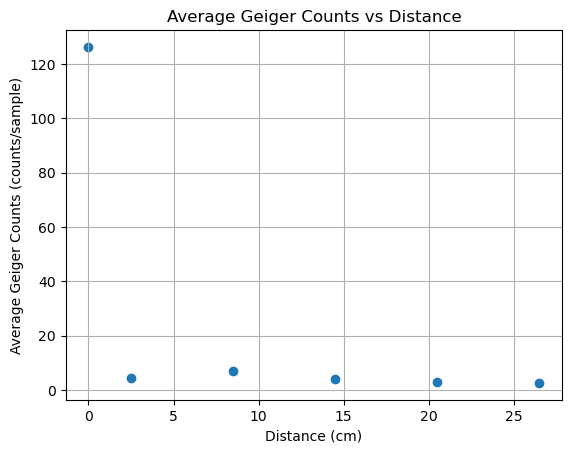

In [7]:
run_length = list(runs.values())
run_averages = list(averages.values())

plt.scatter(run_length, run_averages)
plt.xlabel("Distance (cm)")
plt.ylabel("Average Geiger Counts (counts/sample)")
plt.title("Average Geiger Counts vs Distance")
plt.grid()

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1e-08, but the percent differences are:
206.539184471231

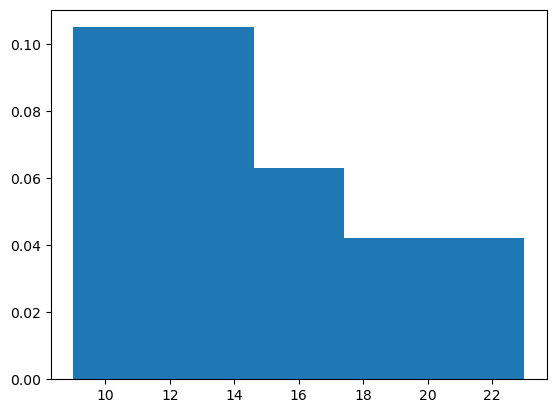

In [11]:
from scipy.stats import norm


bin = 5
for filename in histogram_data_names:
    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()
    plt.figure()
    plt.hist(data, bins=bin, alpha=1, density=True, label="Histogram")
    
    mew = np.mean(data)
    sigma = np.std(data)
    """
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{difference_percent}%")"""
    
    
    x = np.arange(np.min(data), np.max(data) + 1)
    
    chi_poisson = chisquare(data,[poisson(val, mew) for val in data])
    chi_gaussian = chisquare(data,[gausian(val, mew, sigma) for val in data])
    print("Poisson" if chi_poisson<chi_gaussian else "Gaussian", min(chi_poisson, chi_gaussian))

    # Gaussian plot
    gauss_y = [gausian(val, mew, sigma) for val in x]
    gauss_y = np.array(gauss_y)
    plt.plot(x, gauss_y, 'r-', label="Gaussian (normalized)")
    
    
    # Poisson plot
    pois_y = [poisson(val, mew) for val in x]
    pois_y = np.array(pois_y)
    
    # Calculate the R^2 value for the Gaussian fit
    hist_vals, bin_edges = np.histogram(data, bins=bin, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    gauss_fit = norm.pdf(bin_centers, mew, sigma)
    ss_res = np.sum((hist_vals - gauss_fit) ** 2)
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"Gaussian fit R^2: {r2:.3f}")
    
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend()
    plt.show()


In [ ]:
some_more = ["Data_5Hz_1min_2.5cm.csv"]
bin = 12
for filename in some_more:
    data = df(f"data/{filename}")[field_names[1]].to_numpy()
    # Use only the first quarter of data points
    quarter_len = len(data)
    data = data[:quarter_len]
    plt.figure()
    plt.hist(data, bins=bin, alpha=1, density=True, label="Histogram")
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{difference_percent}%")
    
    
    
    
    x = np.arange(np.min(data), np.max(data) + 1)
    
    
    
    

    # Gaussian plot
    gauss_y = [gausian(val, mew, sigma) for val in x]
    gauss_y = np.array(gauss_y)
    plt.plot(x, gauss_y, 'r-', label="Gaussian (normalized)")
    
    # Calculate the R^2 value for the Poisson fit
    pois_fit = np.array([poisson(val, mew) for val in bin_centers])
    ss_res_pois = np.sum((hist_vals - pois_fit) ** 2)
    ss_tot_pois = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2_pois = 1 - (ss_res_pois / ss_tot_pois)
    print(f"Poisson fit R^2: {r2_pois:.3f}")
    
    # Poisson plot
    pois_y = [poisson(val, mew) for val in x]
    pois_y = np.array(pois_y)
    
    # Calculate the R^2 value for the Gaussian fit
    hist_vals, bin_edges = np.histogram(data, bins=bin, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    gauss_fit = norm.pdf(bin_centers, mew, sigma)
    ss_res = np.sum((hist_vals - gauss_fit) ** 2)
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"Gaussian fit R^2: {r2:.3f}")
    
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend()
    plt.show()